Found 4541 images.


Extracting ORB features:   0%|          | 0/4541 [00:00<?, ?it/s]

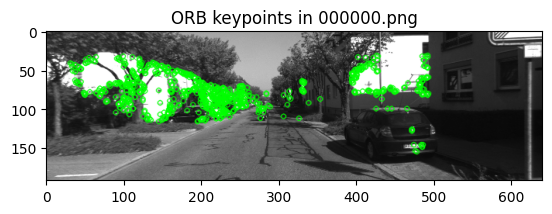

Extracting ORB features:   0%|          | 1/4541 [00:00<13:03,  5.80it/s]

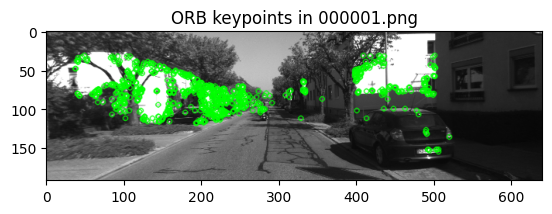

Extracting ORB features:   0%|          | 2/4541 [00:00<09:49,  7.69it/s]

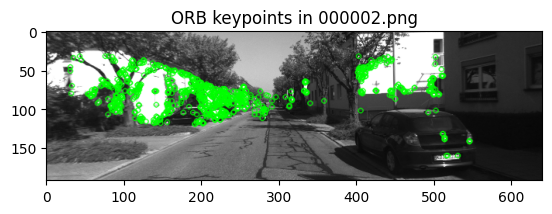

Extracting ORB features: 100%|██████████| 4541/4541 [00:27<00:00, 166.51it/s]

Saved descriptors → orb_descriptors_seq00.npy


In [1]:
import cv2
import os
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

# -----------------------------
# 1. Set paths
# -----------------------------
SEQ_PATH = "/Users/kalyanibalmiki/Downloads/dataset/sequences/00/image_0"   
SAVE_DESCRIPTORS = True                                # store features for later matching

# -----------------------------
# 2. ORB feature extractor
# -----------------------------
orb = cv2.ORB_create(
    nfeatures=1000,     # number of keypoints per image
    scaleFactor=1.2,
    nlevels=8,
    edgeThreshold=31,
    firstLevel=0,
    WTA_K=2,
    scoreType=cv2.ORB_HARRIS_SCORE,
    patchSize=31,
    fastThreshold=20
)

# -----------------------------
# 3. Read all image files
# -----------------------------
image_files = sorted([os.path.join(SEQ_PATH, f) for f in os.listdir(SEQ_PATH) if f.endswith('.png')])
print(f"Found {len(image_files)} images.")

# -----------------------------
# 4. Loop through images & extract features
# -----------------------------
features = []  # list of (keypoints, descriptors)

for img_path in tqdm(image_files, desc="Extracting ORB features"):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    
    # Optional preprocessing
    img = cv2.resize(img, (640, 192))  # resize for consistency
    
    keypoints, descriptors = orb.detectAndCompute(img, None)
    features.append((keypoints, descriptors))
    
    # Visualization for first few images
    if len(features) <= 3:
        img_kp = cv2.drawKeypoints(img, keypoints, None, color=(0,255,0), flags=0)
        plt.imshow(img_kp, cmap='gray')
        plt.title(f"ORB keypoints in {os.path.basename(img_path)}")
        plt.show()

# -----------------------------
# 5. Save descriptors for later (optional)
# -----------------------------
if SAVE_DESCRIPTORS:
    descriptors_list = [f[1] for f in features]  # list of descriptor arrays
    np.save("orb_descriptors_seq00.npy", np.array(descriptors_list, dtype=object))
    print("Saved descriptors → orb_descriptors_seq00.npy")


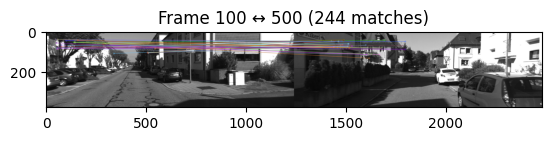

In [2]:
# -----------------------------
# 6. Descriptor Matching
# -----------------------------
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

# Example: match frame i with frame j (e.g., j = i + 50)
i, j = 100, 500
desc1 = features[i][1]
desc2 = features[j][1]

if desc1 is not None and desc2 is not None:
    matches = bf.match(desc1, desc2)
    matches = sorted(matches, key=lambda x: x.distance)

    img1 = cv2.imread(image_files[i], cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(image_files[j], cv2.IMREAD_GRAYSCALE)
    img_matches = cv2.drawMatches(img1, features[i][0], img2, features[j][0], matches[:50], None, flags=2)
    plt.imshow(img_matches)
    plt.title(f"Frame {i} ↔ {j} ({len(matches)} matches)")
    plt.show()


In [3]:
# -----------------------------
# 7. Place Recognition (Revisit Detection)
# -----------------------------
N = len(features)
top_matches = []

for i in tqdm(range(100, N, 20), desc="Detecting revisits"):
    desc_i = features[i][1]
    if desc_i is None:
        continue

    best_score, best_j = 0, -1
    for j in range(0, i - 50, 20):  # avoid nearby frames
        desc_j = features[j][1]
        if desc_j is None:
            continue
        matches = bf.match(desc_i, desc_j)
        if len(matches) == 0:
            continue
        avg_dist = np.mean([m.distance for m in matches])
        score = 1 / avg_dist
        if score > best_score:
            best_score, best_j = score, j

    if best_j != -1:
        top_matches.append((i, best_j, best_score))



etecting revisits: 100%|██████████| 223/223 [00:36<00:00,  6.14it/s]